![imagen](img/python.jpg)

# Streamlit

Streamlit es un paquete de Python que te permite crear y compartir aplicaciones de datos.

Utiliza **uv** para iniciar un proyecto.

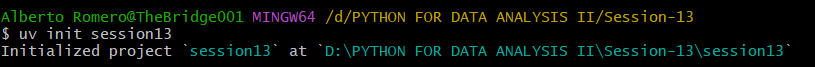

Ve al **repositorio del proyecto** y crea un **entorno virtual**.

Activa el **entorno virtual** (.venv). Una vez activado, deberías ver el nombre del proyecto en el indicador de la terminal.

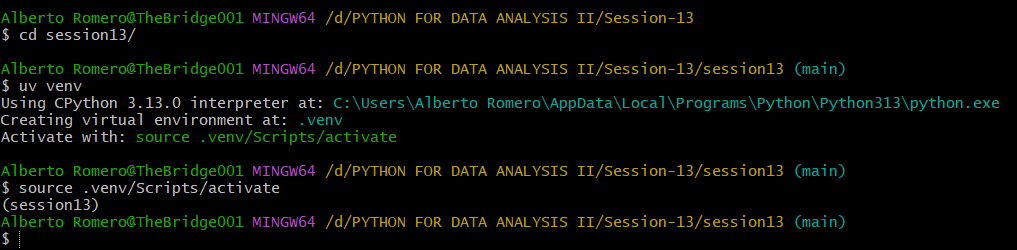

Añade **streamlit** al entorno virtual.

```bash
uv add streamlit==1.32.2
```

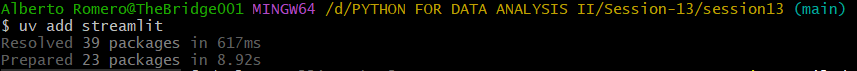

Date cuenta de que la instalación de **streamlit** tiene dependencias y **streamlit** instalará **pandas** o **numpy** también.

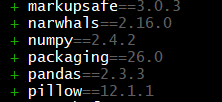

Para este proyecto de **streamlit** también necesitaremos:
```python
altair==5.3.0
Pillow==10.4.0
plotly==5.22.0
pydeck[jupyter]==0.8
streamlit-lottie==0.0.5
pyarrow==15.0.2

```

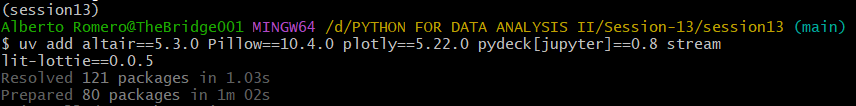

Aquí tienes el script **main_part1.py** que ejecutaremos:

```python
import streamlit as st
import pandas as pd
import numpy as np
import json
from streamlit_lottie import st_lottie
import os

st.set_page_config(page_title = "SUPERSTORE", page_icon=":chart", layout = "centered")
st.title("SuperStore Group")

st.subheader("Intro")
my_path1 = os.path.join("data","office.jpg")
st.image(my_path1, use_column_width="strecht")

st.markdown("""**SuperStore** is the leading group in the office technology, supplies and equipment sector in the *United States*. The group was founded over 30 years ago in Detroit (USA). It was the first 
        company to develop a B2B online purchasing platform for workplace materials 
        in 1999. Its catalogue includes technology products, supplies and office equipment. 
        Today, it has over 60,000 corporate customers in the USA.""")

st.write("Superstore")

with st.expander("Sustainability"):
    st.markdown("""SuperStore ensures that all steps taken to satisfy its customers are carried out in the 
most sustainable manner possible.""")
    st.markdown("""
        * More than half of the products are organic. \n
        * The group has reduced its CO2 emissions by a third (since 2010). \n
        * It has also minimised packaging and optimised its transport routes.""")
    
uploaded_file = st.file_uploader("Upload CSV", type = ["csv"])

if uploaded_file is not None:
    dataset = pd.read_csv(uploaded_file, parse_dates = ["Order Date"])
    dataset["Order Date Year"] = dataset["Order Date"].dt.strftime('%Y')
    
    if st.button("See data"):
        st.markdown("<h3 style='text-align: center; color:red;'>DataFrame (2013 - 2016)</h3>", unsafe_allow_html=True)
        st.dataframe(dataset)
        pivot_table = pd.pivot_table(dataset, values = "Sales", index = "Order Date Year",  columns = "Region", aggfunc = "sum").copy()
        st.markdown("<p style='text-align: center;'>Total sales per state (2013 - 2016)</p>", unsafe_allow_html=True)
        st.line_chart(pivot_table)
        st.balloons()
        st.snow()
        my_path = os.path.join("data","animation.json")
        with open(my_path) as source:
            animation = json.load(source)
        st_lottie(animation, height=100, width=100)
```

### **Corre streamlit**


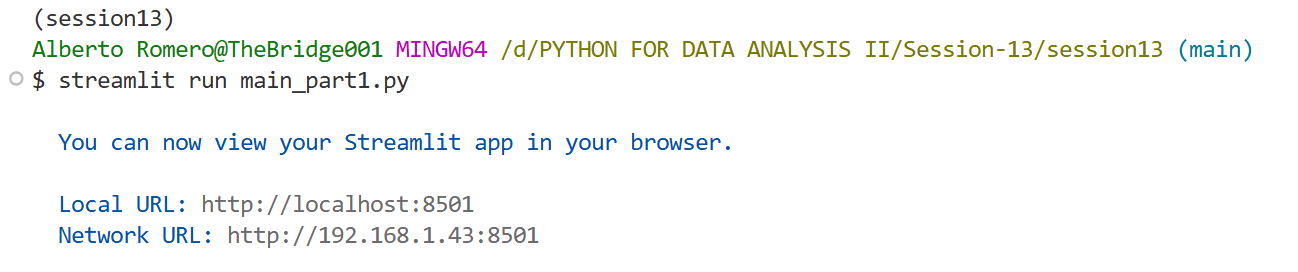

Y podemos comprobar que tenemos la página web (la aplicación de streamlit) corriéndola en **localhost**.

**8501** es el puerto que usa Streamlit.

Localhost significa que no estamos realmente en internet, sino localmente. Sin embargo, podríamos haber desplegado nuestra aplicación en un servicio cloud (ponerla en internet).

De momento nos vamos a centrar en tener una aplicación funcionando en local.

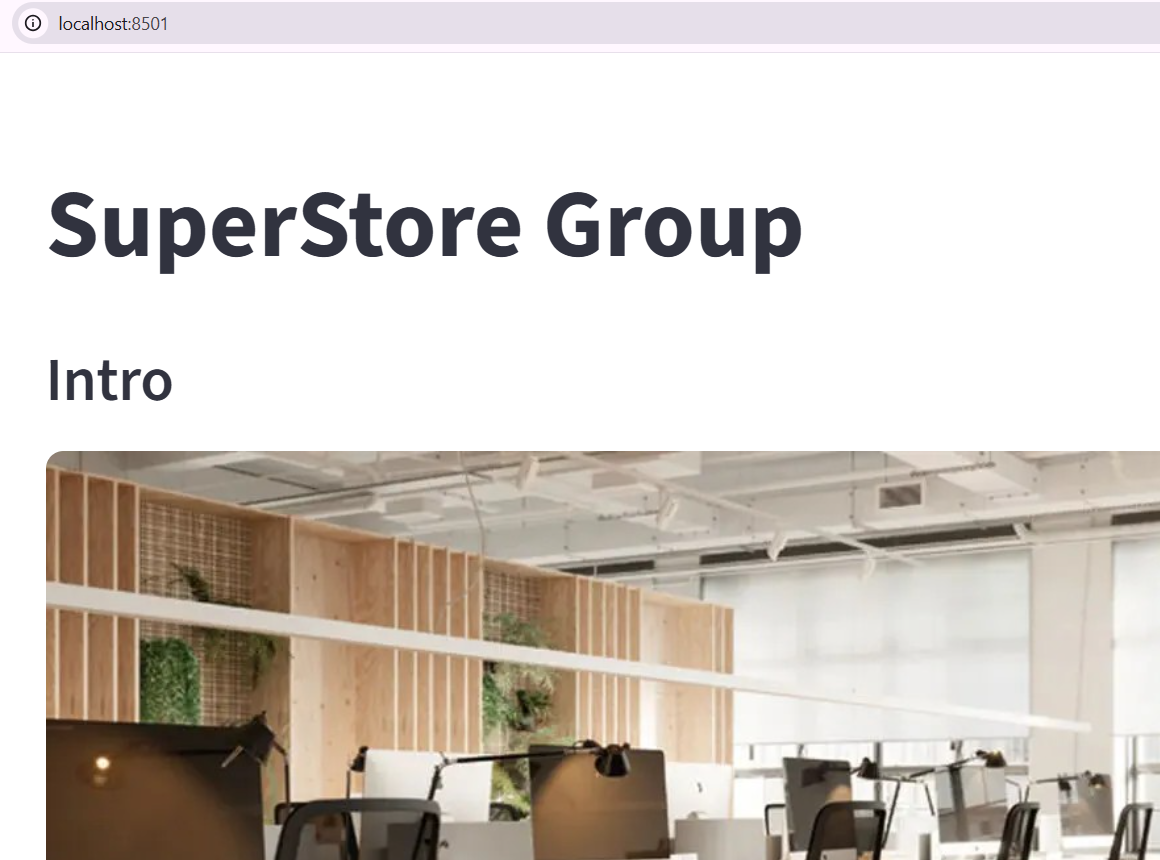


#### Como puedes apreciar, streamlit  es usar python para tener una manera amigable de programar un frontend con python.


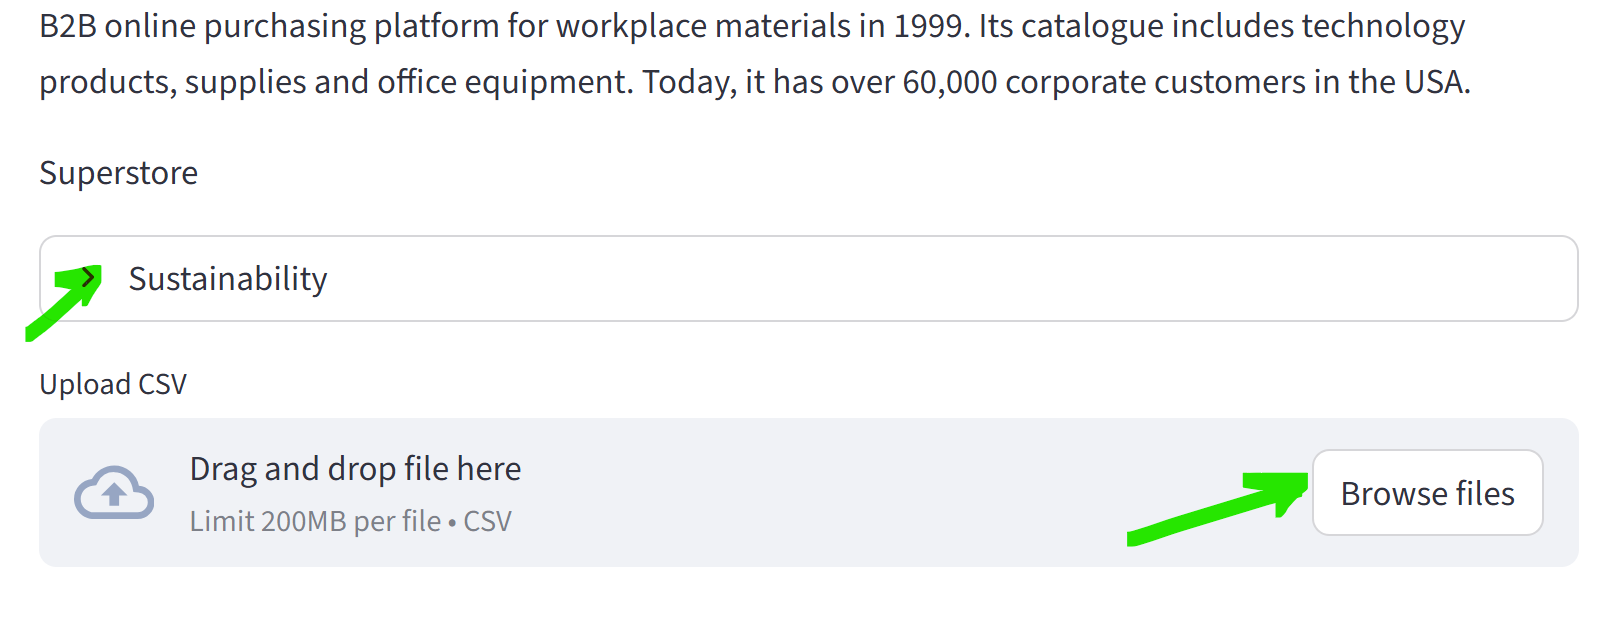


Hacemos click para expandir Sustainability:

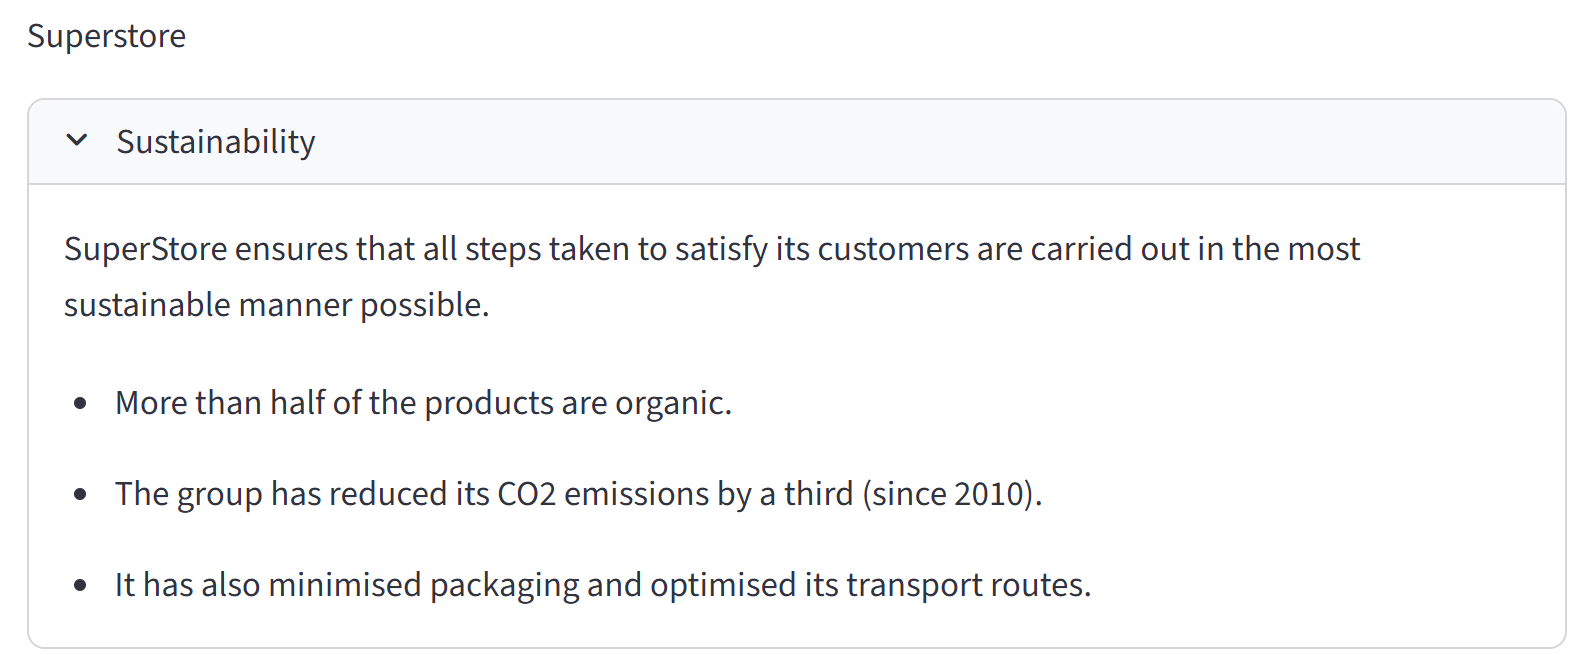

Y después cargamos el fichero csv:

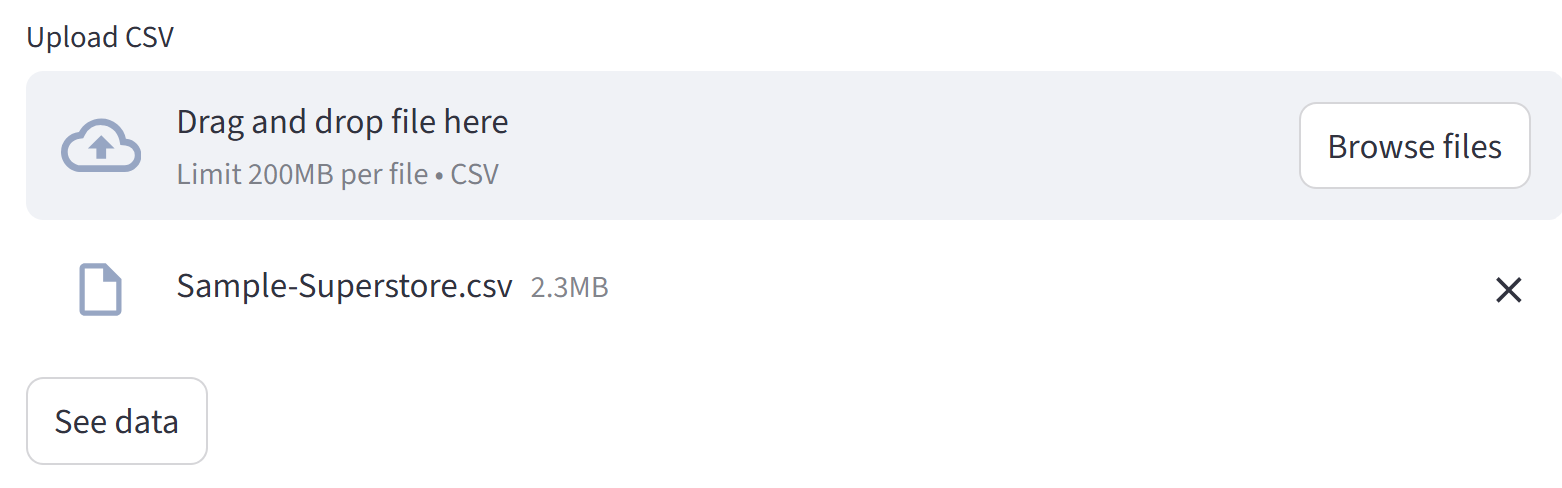

Si haces click en "See data", verás los datos.

Si bajas la barra de scroll, ¡verás los globos!

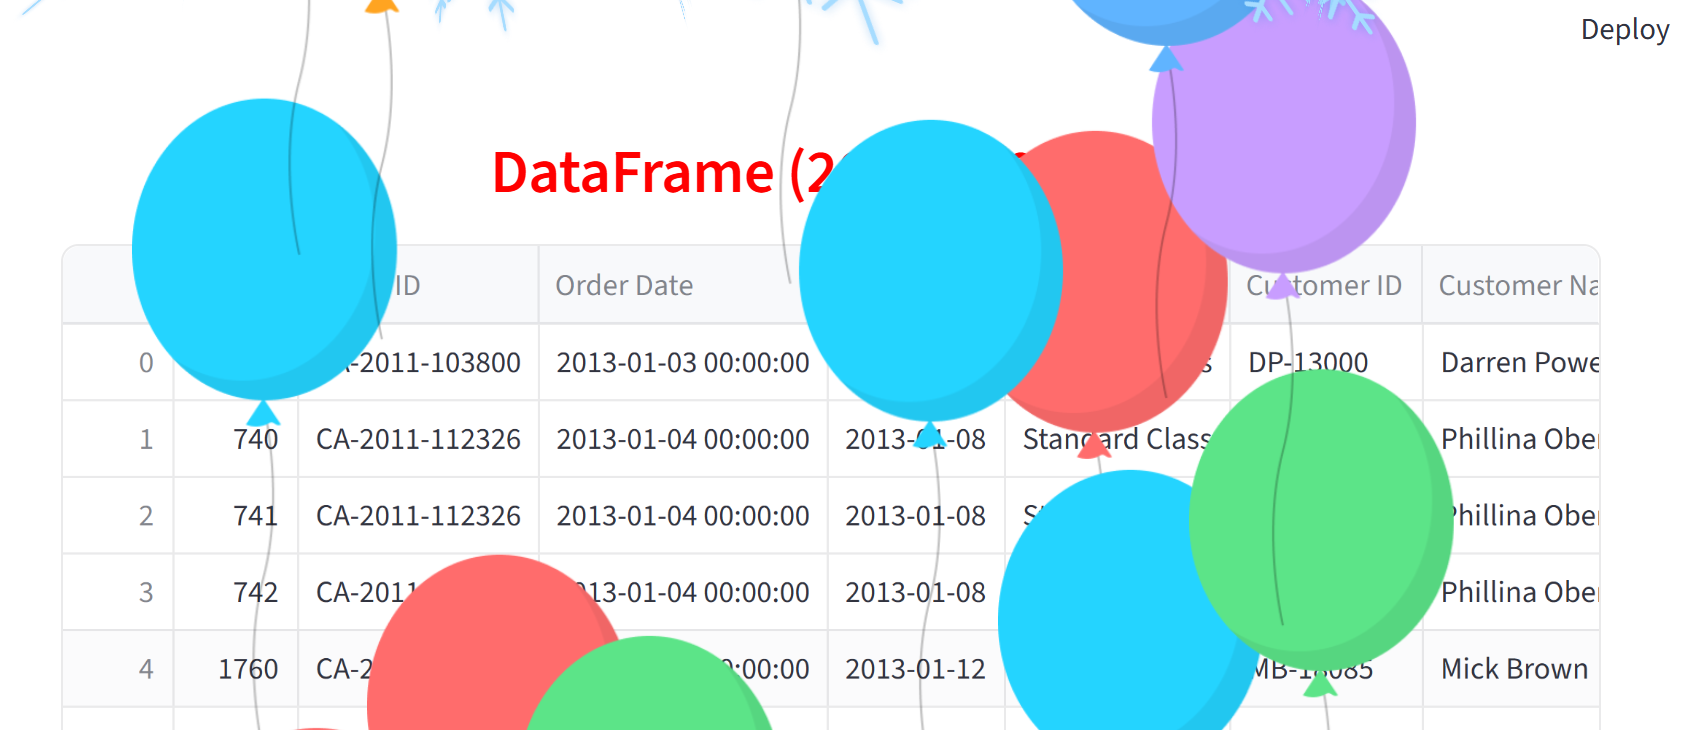

En la parte de abajo encontrarás el gif de un pato (streamlit-lottie)

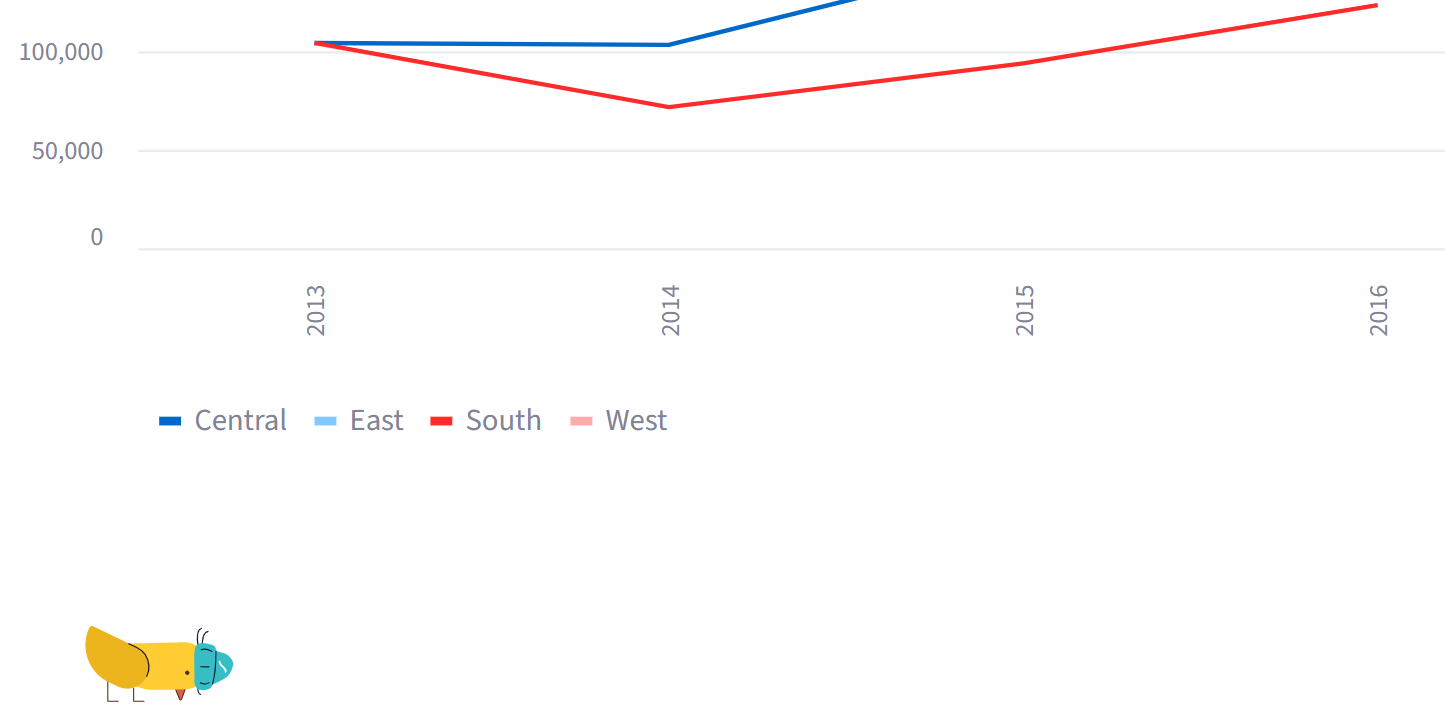

### Streamlit con un script de funciones

¡Mejoremos nuestro ejemplo!

Este es el fichero **functions.py**.

```python
import streamlit as st
import json
import pandas as pd
from streamlit_lottie import st_lottie
from PIL import Image
import numpy as np
import plotly.express as px
import pydeck as pdk
import os


def config_page():
    st.set_page_config(page_title = "SUPERSTORE", page_icon=":chart:", layout="centered")

def home():
    st.title("Grupo SuperStore")

    st.subheader("Intro")
    
    my_path1 = os.path.join("data","office.jpg")
    img = Image.open(my_path1)
    st.image(img, use_column_width=True)

    st.markdown("""**SuperStore** is the leading group in the office technology, supplies and equipment sector in the *United States*. The group was founded over 30 years ago in Detroit (USA). It was the first 
        company to develop a B2B online purchasing platform for workplace materials 
        in 1999. Its catalogue includes technology products, supplies and office equipment. 
        Today, it has over 60,000 corporate customers in the USA.""")

    with st.expander("Sustainability"):
        st.markdown("""SuperStore ensures that all steps taken to satisfy its customers are carried out in the 
most sustainable manner possible.""")
        st.markdown("""
        * More than half of the products are organic. \n
        * The group has reduced its CO2 emissions by a third (since 2010). \n
        * It has also minimised packaging and optimised its transport routes.""")

def charge_data(): 
    uploaded_file = st.file_uploader("Upload CSV", type=["csv"])
    
    if uploaded_file is not None: 
        global dataset  # Notice how we make the variable global to be accessible outside of the function!! Now it is not local
        dataset = pd.read_csv(uploaded_file, parse_dates=["Order Date"])
        dataset["Order Date Year"] = dataset["Order Date"].dt.strftime('%Y')
                
        if st.button("See data"):
            st.markdown("<h3 style='text-align: center; color: red;'>DataFrame (2013 - 2016)</h3>", unsafe_allow_html=True)
            st.dataframe(dataset)
            pivot_table = pd.pivot_table(dataset, values="Sales", columns="Region", index="Order Date Year", aggfunc="sum").copy()
            st.markdown("<p style='text-align: center;'>Total sales per state (2013 - 2016)</p>", unsafe_allow_html=True)
            
            st.line_chart(pivot_table)
            st.balloons()
            st.snow()
            my_path = os.path.join("data", "animation.json")
            with open(my_path) as source:
                animation = json.load(source)
            st_lottie(animation, height=100, width=100)

def sales_cat_table():

    #Sales table per category
    dataset_sales = pd.DataFrame(dataset.groupby("Category")["Sales"].sum())
    
    dataset_sales ["Percentage"] = ((dataset_sales ["Sales"] /dataset_sales ["Sales"].sum())*100).round(2)
    dataset_sales ["Percentage"] = dataset_sales ["Percentage"].astype(str) + " %"  
    dataset_sales ["Sales"] = dataset_sales ["Sales"].astype("int")
    
    st.table(dataset_sales)
    return dataset_sales

def sales_cat_barplot():

    df_sales_cat = dataset.groupby(["Order Date Year","Category"])["Sales"].sum().reset_index()
    
    # bar plot    
    fig1 = px.bar(df_sales_cat, 
              x="Order Date Year",
              y = "Sales",
             color='Category',
             labels={"Order Date Year":''},
             color_discrete_sequence = px.colors.qualitative.Antique,
             height=500, 
             width=600)

    fig1.update_layout(font=dict(size=9),title_text="Sales of items per category and year")

    return fig1

def sales_subcat_barplot():

    dataset_subcat = dataset.groupby(["Order Date Year", "Category", "Sub-Category"])["Sales"].sum().reset_index()
    
    year = st.slider('Please, select a year', 2013, 2016)
    
    if year == 2013:
        data = dataset_subcat[dataset_subcat["Order Date Year"] == "2013"]
    elif year == 2014:
        data = dataset_subcat[dataset_subcat["Order Date Year"] == "2014"]
    elif year == 2015:
        data = dataset_subcat[dataset_subcat["Order Date Year"] == "2015"]
    else:
        data = dataset_subcat[dataset_subcat["Order Date Year"] == "2016"]
    
    # bar plot

    fig2 = px.bar(data, 
              x="Sub-Category",
              y = "Sales",
             color='Category',
             template="plotly_white",
             labels={"Order Date Year":'',"Sub-Category":" "},
             color_discrete_sequence = px.colors.qualitative.Antique,
             height=500, 
             width=600,
             title = "Sales per Sub-category year "+ str(year))

    fig2.update_layout(font=dict(size=20))

    return fig2


def sales_subcat_lc():
    
    dataset_order_date_subcat = dataset.groupby(["Order Date Year", "Sub-Category"])["Sales"].sum().reset_index()
    
    year = st.slider('Which years do you want to select?', 2013, 2016,(2013, 2016))
    
    with st.sidebar:
        sub_category = st.multiselect('Choose the Sub-Category', ['Paper', 'Labels', 'Storage', 'Binders', 'Art', 'Chairs', 'Phones',
       'Fasteners', 'Furnishings', 'Accessories', 'Envelopes',
       'Bookcases', 'Appliances', 'Tables', 'Supplies', 'Machines',
       'Copiers'], ['Paper', 'Labels', 'Storage', 'Binders', 'Art', 'Chairs', 'Phones',
       'Fasteners', 'Furnishings', 'Accessories', 'Envelopes',
       'Bookcases', 'Appliances', 'Tables', 'Supplies', 'Machines',
       'Copiers'])
    
    #line chart
    list_columns = []
    if year[0] != year[1]:
        if sub_category != []:
            
            for i in range(len(sub_category)):
                list_columns.append(sub_category[i])
                
            st.subheader("Sales of sub-category per year")
            df_sub_categ_mask = dataset_order_date_subcat[dataset_order_date_subcat["Sub-Category"].isin(list_columns)]
                        
            fig3 = px.line(df_sub_categ_mask[df_sub_categ_mask["Order Date Year"].isin([str(x) for x in np.arange(year[0], year[1] + 1)])],
                           x = "Order Date Year",
                           y = "Sales",
                           color= "Sub-Category",
                           labels={"Order Date Year":'',"Sub-Category":" "},
                           title='Sales Sub-Category year',
                           height=700, 
                            width=700,
                            markers=True
            )
            return fig3
        else: 
            return 2
    else:
        return 1 
    

def sales_state():
    my_path3 = os.path.join("data","statelatlong.csv")
    df_cities = pd.read_csv(my_path3)
    dataset2 = dataset.copy()
    dataset2["Order Date Year"] = dataset2["Order Date"].dt.year
    df_map = dataset2.groupby(["State", "Order Date Year"])[["Sales"]].sum().reset_index().merge(df_cities, left_on="State", right_on="City").drop(columns=["State_y", "City"]).rename(columns={"State_x":"State"})

    years =[2013, 2014, 2015, 2016]
    sell_year = st.selectbox('Choose the year', years)
    if sell_year in years:   
        year_to_show = sell_year
    
    view = pdk.ViewState(latitude=37, longitude=-95, zoom=3,)
    
    tooltip = {
        "html":
            "<b>State:</b> {State} <br/>"
            "<b>Sales:</b> {Sales} <br/>",
        "style": {
            "backgroundColor": "steelblue",
            "color": "black",
        }
    }
    salesLayer = pdk.Layer(
            type= "ScatterplotLayer",
            data=df_map,
            pickable=True,
            opacity=0.3,
            filled=True,
            onClick=True,
            radius_scale=10,
            radius_min_pixels=0,
            radius_max_pixels=30,
            line_width_min_pixels=1,
            get_position=["Longitude", "Latitude"],
            get_radius="Sales",
            get_fill_color=[252, 136, 3],
            get_line_color=[255,0,0],
        )

    r = pdk.Deck(
        layers=[salesLayer],
        initial_view_state=view,
        map_style="mapbox://styles/mapbox/light-v10",
        tooltip=tooltip,
    )
    map = st.pydeck_chart(r)
    salesLayer.data = df_map[df_map['Order Date Year'] == year_to_show]
  
    r.update()
    map.pydeck_chart(r)
  
```



Y aquí tenemos el script main final, **main_final.py**.

```python

import streamlit as st
import functions as ft



## Basic setup and app layout

ft.config_page()

menu = st.sidebar.selectbox("Choose a section",("Overview",  "Upload your data", "Analyse sales"))

if menu == "Overview": 
    ft.home()

elif menu == "Upload your data":
    ft.charge_data()

else:
    sales_menu = st.sidebar.radio("Choose what you want to analyse",options=["Sales per category", "Sales per subcategory", "Sales per state"])

    if sales_menu == "Sales per category":

        st.header("Sales per category")

        table = ft.sales_cat_table()

        fig1 = ft.sales_cat_barplot()

        st.plotly_chart(fig1, width="stretch")

    elif sales_menu == "Sales per subcategory":

        st.header("Sales per subcategory of items")

        fig2 = ft.sales_subcat_barplot()

        st.plotly_chart(fig2,width="stretch")

        fig3 = ft.sales_subcat_lc()
        
        if fig3 == 1:
           st.write("Choose a range of years to filter")
        elif fig3 == 2:
            st.write("Choose the category/ies to filter")
        else:
            st.plotly_chart(fig3,width="stretch")

    else:
        ft.sales_state()

```



Puedes filtrar las categorías con plotly:

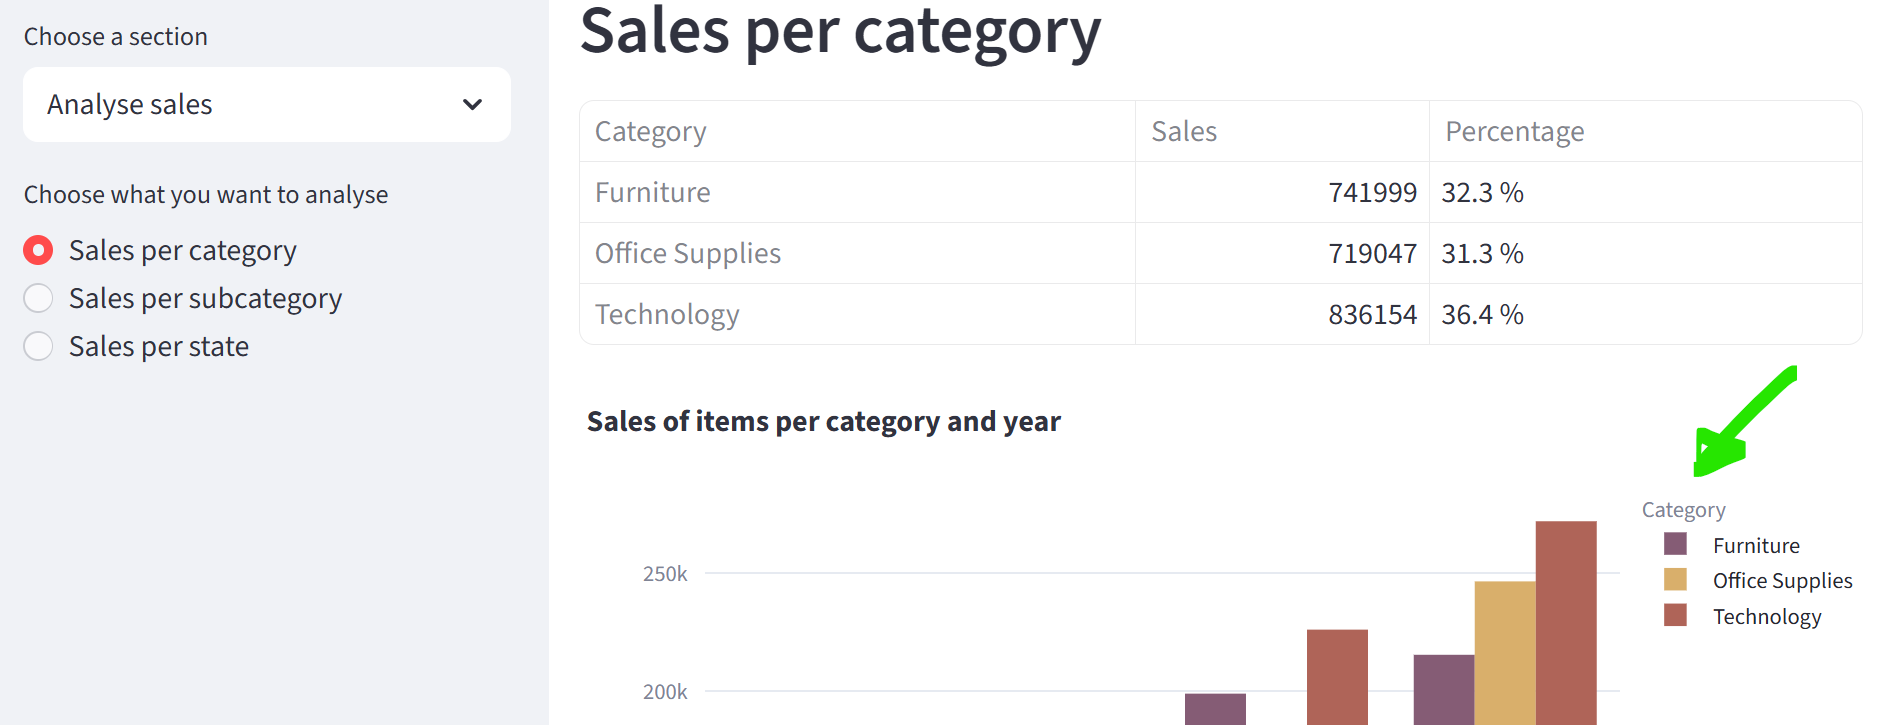

## Compara con el gráfico filtrado:

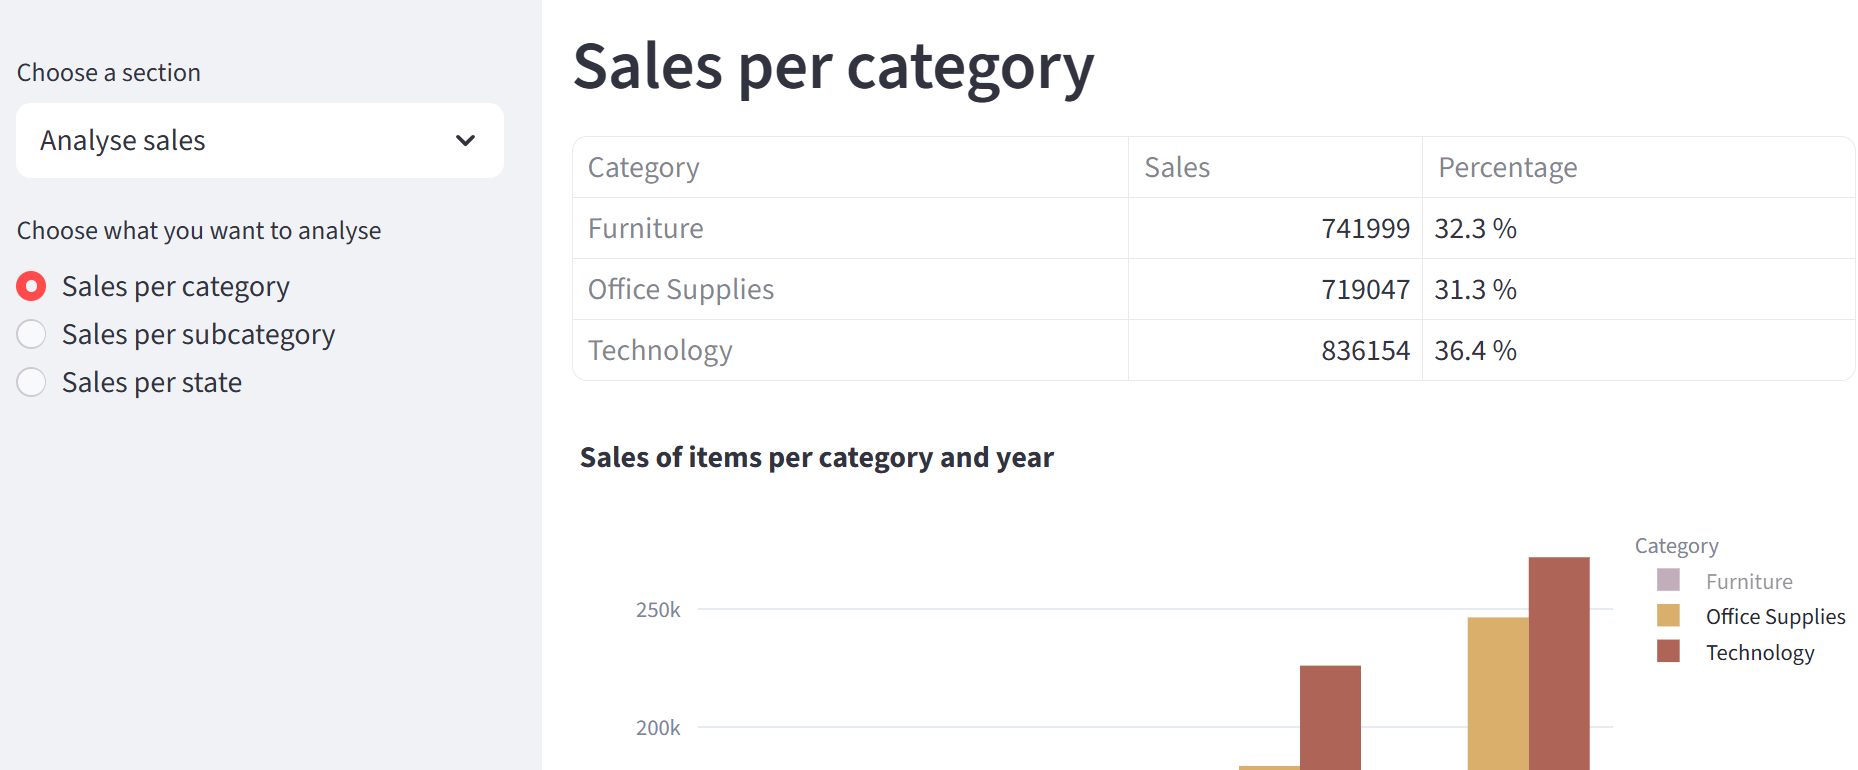

## Puedes filtrar por categoría.

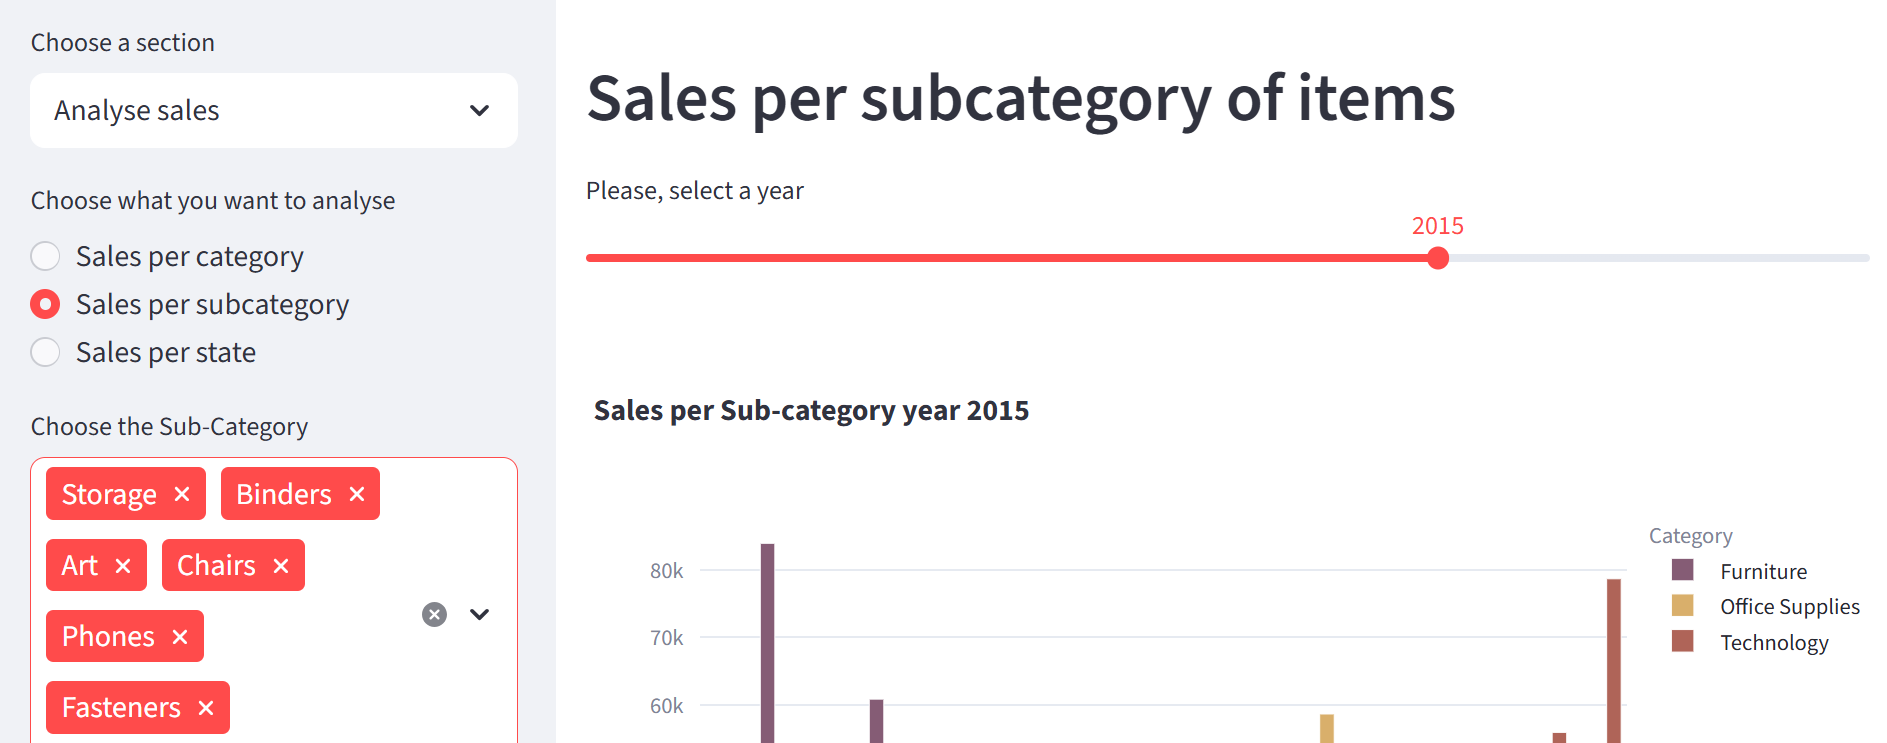

## Puedes ver las ventas por estado.

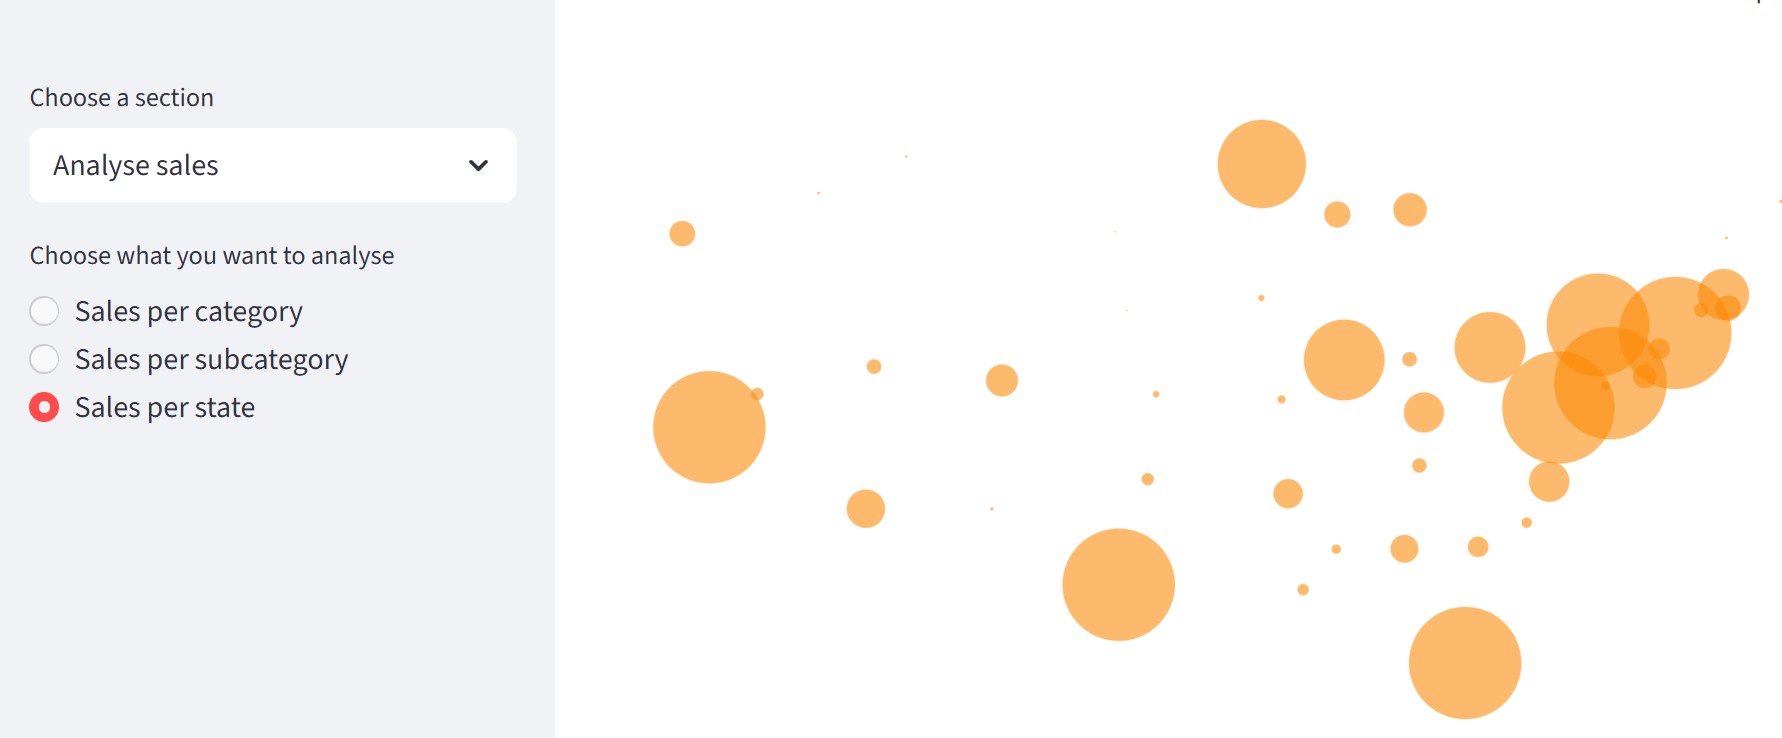

### ¿Quieres explorar más?

La documentación de Streamlit te ofrece la API, así como tambiñen código de proyectos Streamlit.


In [ ]:
# https://docs.streamlit.io/develop/api-reference

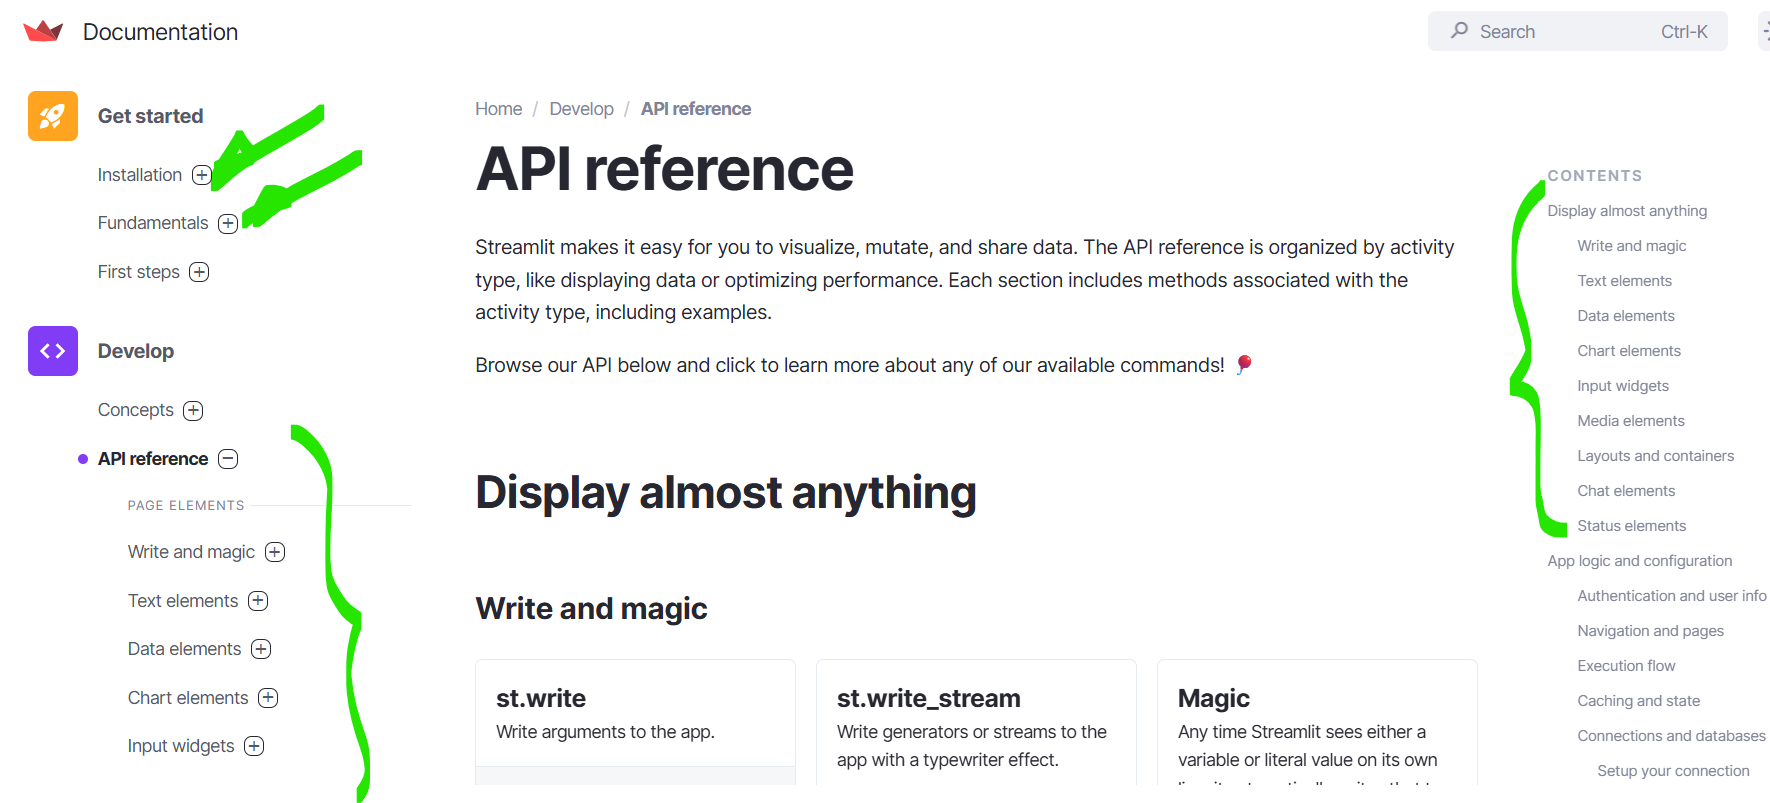